# Notebook 04 — Evaluate ResNet50
✔ Show accuracy requirement  ✔ Visual predictions requirement

## Cell 1 — Imports and load saved model

In [1]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from PIL import Image
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load saved model
ckpt        = torch.load("resnet50_campus.pth", map_location=device)
classes     = ckpt["classes"]
NUM_CLASSES = ckpt["num_classes"]

model = models.resnet50(pretrained=False)
model.fc = nn.Sequential(
    nn.Linear(2048, 512), nn.ReLU(),
    nn.Dropout(0.4), nn.Linear(512, NUM_CLASSES))
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(device)
model.eval()
print(f"✓ Model loaded — {NUM_CLASSES} classes: {classes}")

c:\Users\darwa\OneDrive\Desktop\campus_navigation_project update\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\darwa\OneDrive\Desktop\campus_navigation_project update\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✓ Model loaded — 6 classes: ['bartels_exterior', 'bergami_exterior', 'dodds_exterior', 'john_and_leona_exterior', 'kaplan_exterior', 'maxy_exterior']


## Cell 2 — Run on test set and print accuracy report
✔ Show accuracy requirement

In [2]:
tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_ds     = datasets.ImageFolder("data/test", transform=tf)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(device)
        preds  = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Overall accuracy
correct  = sum(p == l for p, l in zip(all_preds, all_labels))
accuracy = correct / len(all_labels) * 100
print(f"Overall Test Accuracy: {accuracy:.1f}%")
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(
    all_labels, all_preds, target_names=classes))

Overall Test Accuracy: 59.2%
CLASSIFICATION REPORT
                         precision    recall  f1-score   support

       bartels_exterior       0.69      0.73      0.71        15
       bergami_exterior       0.48      0.93      0.63        14
         dodds_exterior       0.00      0.00      0.00         3
john_and_leona_exterior       0.00      0.00      0.00         3
        kaplan_exterior       0.00      0.00      0.00         2
          maxy_exterior       0.83      0.42      0.56        12

               accuracy                           0.59        49
              macro avg       0.33      0.35      0.32        49
           weighted avg       0.55      0.59      0.53        49



c:\Users\darwa\OneDrive\Desktop\campus_navigation_project update\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\darwa\OneDrive\Desktop\campus_navigation_project update\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\darwa\OneDrive\Desktop\campus_navigation_project update\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

## Cell 3 — Confusion matrix

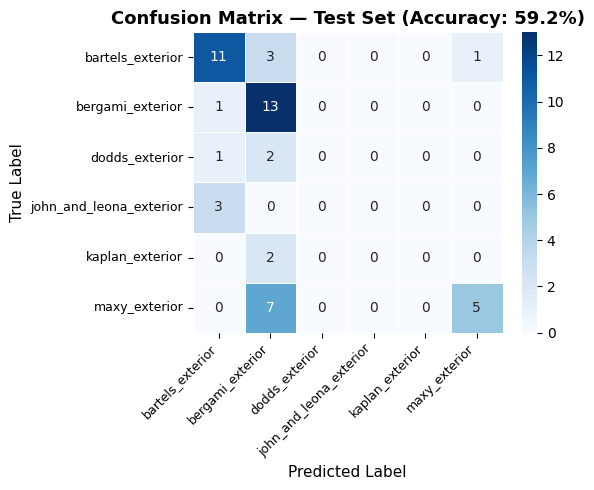

✓ Saved as confusion_matrix.png


In [3]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(max(6, len(classes)), max(5, len(classes)-1)))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=classes, yticklabels=classes,
            cmap="Blues", linewidths=0.5)
plt.title(f"Confusion Matrix — Test Set (Accuracy: {accuracy:.1f}%)",
          fontsize=13, fontweight="bold")
plt.ylabel("True Label", fontsize=11)
plt.xlabel("Predicted Label", fontsize=11)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved as confusion_matrix.png")

## Cell 4 — Visual predictions grid on test photos
✔ Visual predictions requirement

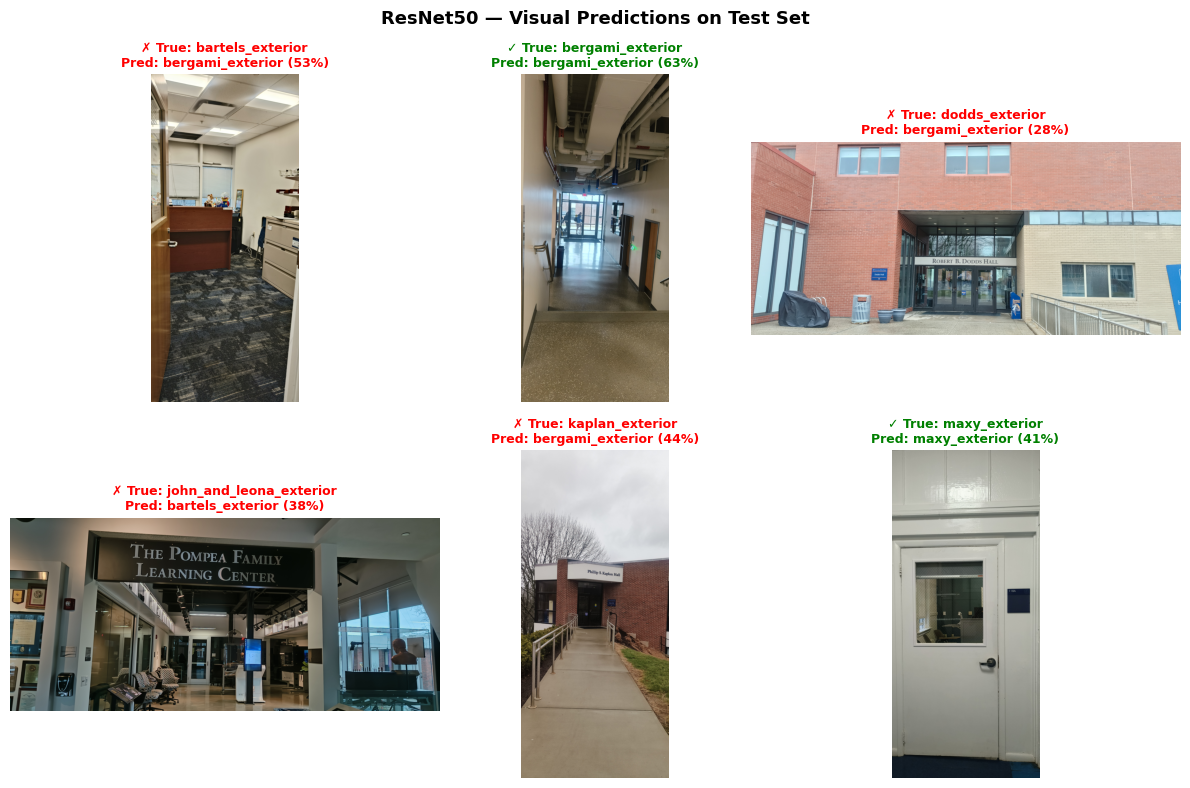

✓ Saved as resnet50_visual_predictions.png
  Green title = correct prediction
  Red title   = wrong prediction


In [4]:
def predict_image(img_path):
    img = Image.open(img_path).convert("RGB")
    t   = tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        out   = model(t)
        probs = torch.softmax(out, dim=1)
        conf, idx = probs.max(dim=1)
    return img, classes[idx.item()], conf.item()

# Collect one image from each class
test_samples = []
for cls in classes:
    folder = f"data/test/{cls}"
    if os.path.exists(folder) and os.listdir(folder):
        img_path = f"{folder}/{os.listdir(folder)[0]}"
        test_samples.append((img_path, cls))

# Plot grid
n     = len(test_samples)
ncols = min(n, 3)
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 4, nrows * 4))
if nrows == 1: axes = [axes]
if ncols == 1: axes = [[ax] for ax in axes]

for i, (img_path, true_cls) in enumerate(test_samples):
    r, c = divmod(i, ncols)
    img, pred_cls, conf = predict_image(img_path)
    correct = (pred_cls == true_cls)
    color   = "green" if correct else "red"
    mark    = "✓" if correct else "✗"
    axes[r][c].imshow(img)
    axes[r][c].set_title(
        f"{mark} True: {true_cls}\nPred: {pred_cls} ({conf:.0%})",
        fontsize=9, color=color, fontweight="bold")
    axes[r][c].axis("off")

# Hide unused axes
for i in range(len(test_samples), nrows * ncols):
    r, c = divmod(i, ncols)
    axes[r][c].axis("off")

plt.suptitle("ResNet50 — Visual Predictions on Test Set",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("resnet50_visual_predictions.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved as resnet50_visual_predictions.png")
print("  Green title = correct prediction")
print("  Red title   = wrong prediction")